In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

KIỂM ĐỊNH THỐNG KÊ (PRE-EDA)

Độ hạt order_items: Trung bình 1.10 items/đơn. Max: 5 items/đơn.

--- TÓM TẮT THỐNG KÊ MÔ TẢ ---
                    count          mean           std          min  \
quantity         714669.0      4.495988      2.290143     1.000000   
unit_price       714669.0   5114.690157   3774.817912   392.570000   
discount_amount  714669.0   1048.887415   2280.530606     0.000000   
zip_x            714669.0  55905.669881  28965.458490  1001.000000   
price            714669.0   5508.186543   3989.319352   440.370000   
cogs             714669.0   4408.043735   3418.129312   249.280605   
zip_y            714669.0  55905.669881  28965.458490  1001.000000   

                          25%           50%           75%       max  
quantity             2.000000      4.000000      6.000000      8.00  
unit_price        1906.890000   4257.770000   7273.760000  43056.00  
discount_amount      0.000000      0.000000    967.630000  35235.47  
zip_x            31329.000000  54901.000000  83861.000000  999

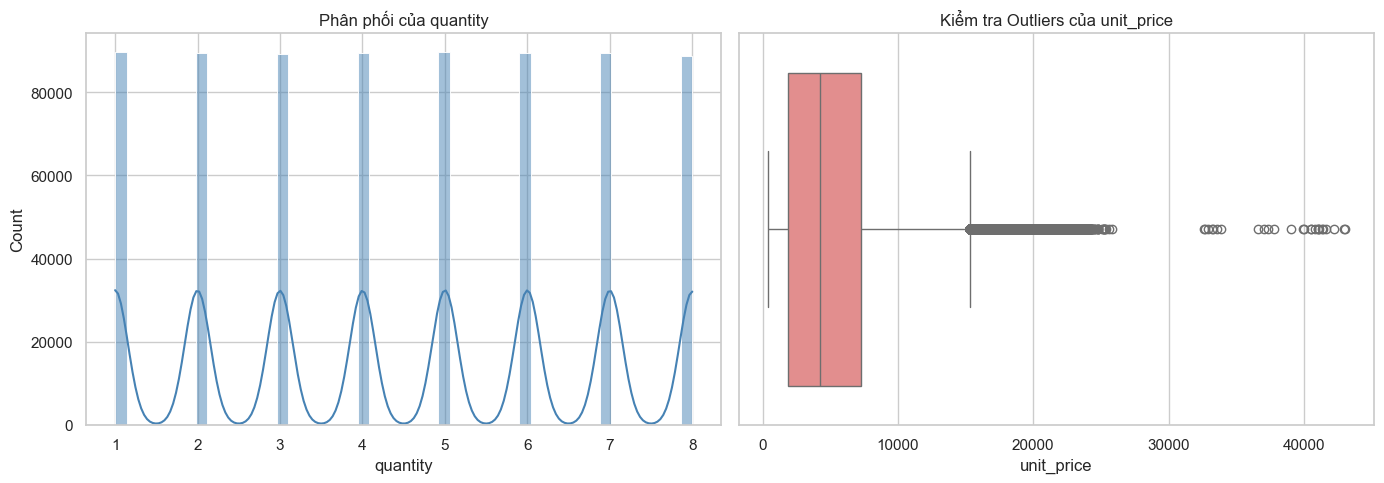

In [3]:
# 1. Load Data (Đường dẫn tương đối từ thư mục code trỏ ngược ra data)
try:
    df_orders = pd.read_csv('dataset/orders.csv')
    df_items = pd.read_csv('dataset/order_items.csv')
    df_products = pd.read_csv('dataset/products.csv')
    df_customers = pd.read_csv('dataset/customers.csv')
except FileNotFoundError as e:
    print(f"Error loading data: {e}. Vui lòng kiểm tra lại cấu trúc thư mục.")

# 2. Xử lý kiểu dữ liệu ngày tháng
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    if col in df_orders.columns:
        df_orders[col] = pd.to_datetime(df_orders[col])

# 3. Kiểm tra độ hạt (Data Granularity) và Cấu trúc Key
# Bảng orders: 1 dòng = 1 đơn hàng (Primary Key: order_id)
assert df_orders['order_id'].nunique() == len(df_orders), "Cảnh báo: Bảng orders có order_id bị trùng lặp."

# Bảng order_items: 1 dòng = 1 sản phẩm trong 1 đơn hàng
# Kiểm tra số lượng sản phẩm trung bình mỗi đơn
items_per_order = df_items.groupby('order_id').size()
print(f"Độ hạt order_items: Trung bình {items_per_order.mean():.2f} items/đơn. Max: {items_per_order.max()} items/đơn.")

# 4. Gom bảng tạo Master DataFrame ban đầu để kiểm định
df_master = df_items.merge(df_orders, on='order_id', how='inner') \
                    .merge(df_products, on='product_id', how='inner') \
                    .merge(df_customers, on='customer_id', how='inner')

# 5. Kiểm định Thống kê (Sửa đổi: Tự động nhận diện biến số)
# Lấy tự động tất cả các cột có kiểu dữ liệu là số (int, float)
numeric_features = df_master.select_dtypes(include=[np.number]).columns.tolist()

# Loại bỏ các cột ID hoặc key khỏi danh sách phân tích thống kê (nếu có)
cols_to_exclude = ['order_id', 'customer_id', 'product_id']
numeric_features = [col for col in numeric_features if col not in cols_to_exclude]

print("\n--- TÓM TẮT THỐNG KÊ MÔ TẢ ---")
print(df_master[numeric_features].describe().T)

print("\n--- KIỂM ĐỊNH PHÂN PHỐI CHUẨN ---")
alpha = 0.05
for col in numeric_features:
    # Bỏ qua nếu cột có quá ít giá trị unique hoặc toàn NaN
    if df_master[col].nunique() < 2 or df_master[col].isnull().all():
        continue
        
    stat, p = stats.normaltest(df_master[col].dropna())
    skewness = df_master[col].skew()
    print(f"{col}: p-value = {p:.2e} | Độ lệch (Skewness): {skewness:.2f}")
    if p < alpha:
        print(f" -> Bác bỏ H0: '{col}' KHÔNG tuân theo phân phối chuẩn.")

# 6. Trực quan hóa (Sửa đổi: Sử dụng biến số đầu tiên có trong data để vẽ)
if len(numeric_features) >= 1:
    col_to_plot_1 = numeric_features[0] # Thường sẽ là price hoặc quantity
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Biểu đồ Histogram
    sns.histplot(df_master[col_to_plot_1], bins=50, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title(f'Phân phối của {col_to_plot_1}')

    # Biểu đồ Boxplot cho biến thứ 2 (nếu có), nếu không dùng lại biến 1
    col_to_plot_2 = numeric_features[1] if len(numeric_features) > 1 else col_to_plot_1
    sns.boxplot(x=df_master[col_to_plot_2], ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Kiểm tra Outliers của {col_to_plot_2}')

    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy biến số nào để trực quan hóa.")

XÂY DỰNG DATAMART & CẤU TRÚC LẠI DỮ LIỆU (DATA PREPARATION)

In [4]:
print(df_master.columns.tolist())

['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2', 'order_date', 'customer_id', 'zip_x', 'order_status', 'payment_method', 'device_type', 'order_source', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs', 'zip_y', 'city', 'signup_date', 'gender', 'age_group', 'acquisition_channel']


In [5]:
# --- DATA PREPARATION & FEATURE ENGINEERING ---
# 1. Ép kiểu thời gian dứt điểm cho cột 'order_date'
# Sử dụng errors='coerce' để biến các giá trị lỗi thành NaT, tránh dừng chương trình
df_master['order_date'] = pd.to_datetime(df_master['order_date'], errors='coerce')
df_master = df_master.dropna(subset=['order_date']) # Loại bỏ dòng hỏng ngày tháng

# 2. Xây dựng Business Metrics (Dựa trên cột thực tế trong data)
# Tổng doanh thu trước chiết khấu
df_master['gross_revenue'] = df_master['unit_price'] * df_master['quantity']

# Doanh thu thuần (Hệ thống thường ghi nhận revenue = gross - discount)
# Nếu cột 'revenue' chưa có trong df_master gốc, ta tạo mới:
if 'revenue' not in df_master.columns:
    df_master['revenue'] = df_master['gross_revenue'] - df_master['discount_amount']

# Lợi nhuận (Hệ thống dùng profit = revenue - cogs)
if 'profit' not in df_master.columns:
    df_master['profit'] = df_master['revenue'] - df_master['cogs']

# 3. Phân tách Datamart
# Profit Datamart: Chỉ các đơn hàng đã giao thành công
df_profit = df_master[df_master['order_status'] == 'delivered'].copy()
df_profit['order_month'] = df_profit['order_date'].dt.to_period('M').astype(str)

# Leakage Datamart: Đơn hoàn trả và Đơn hủy
df_returned = df_master[df_master['order_status'] == 'returned'].copy()
df_cancelled = df_master[df_master['order_status'].astype(str).str.contains('cancel', case=False)].copy()

print("Hoàn tất chuẩn bị Datamart. Sẵn sàng trực quan hóa.")

Hoàn tất chuẩn bị Datamart. Sẵn sàng trực quan hóa.


BUSINESS EDA VISUALIZATION

In [6]:
# --- BUSINESS EDA VISUALIZATION (Đã cấu hình mở trên Trình duyệt) ---
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# BẬT TÍNH NĂNG BYPASS: Ép Plotly mở biểu đồ trên trình duyệt web
pio.renderers.default = "browser"

# BIỂU ĐỒ 1: XU HƯỚNG DOANH THU & BIÊN LỢI NHUẬN (Trend Analysis)
monthly_trend = df_profit.groupby('order_month').agg(
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum')
).reset_index()
monthly_trend['gpm_pct'] = (monthly_trend['total_profit'] / monthly_trend['total_revenue']) * 100

fig1 = go.Figure()
fig1.add_trace(go.Bar(x=monthly_trend['order_month'], y=monthly_trend['total_revenue'], name='Doanh thu', marker_color='royalblue', yaxis='y1'))
fig1.add_trace(go.Scatter(x=monthly_trend['order_month'], y=monthly_trend['gpm_pct'], name='Tỷ suất LN (%)', mode='lines+markers', line=dict(color='crimson', width=3), yaxis='y2'))
fig1.update_layout(title='Xu hướng Doanh thu và Biên lợi nhuận gộp', yaxis=dict(title='Doanh thu'), yaxis2=dict(title='GPM %', overlaying='y', side='right'), template='plotly_white')
fig1.show() # Lệnh này giờ sẽ tự động mở 1 tab Chrome/Edge mới

# BIỂU ĐỒ 2: PHÂN LỚP LỢI NHUẬN (Bubble Chart theo Segment)
segmentation_df = df_profit.groupby(['category', 'segment']).agg(
    total_qty=('quantity', 'sum'),
    total_rev=('revenue', 'sum'),
    total_prof=('profit', 'sum')
).reset_index()
segmentation_df['margin'] = (segmentation_df['total_prof'] / segmentation_df['total_rev']) * 100

fig2 = px.scatter(segmentation_df, x='total_qty', y='margin', size='total_rev', color='category', hover_name='segment',
                 title='Phân tích Lợi nhuận: Sản lượng vs Tỷ suất (Bubble size = Doanh thu)', template='plotly_white')
fig2.show() # Tự động mở tab thứ 2

# BIỂU ĐỒ 3: MA TRẬN LỢI NHUẬN THEO NHÂN KHẨU HỌC (Demographic Heatmap)
demo_pivot = df_profit.pivot_table(index='category', columns='age_group', values='profit', aggfunc='sum').fillna(0)
fig3 = px.imshow(demo_pivot, color_continuous_scale='Viridis', title='Heatmap Lợi nhuận theo Ngành hàng và Nhóm tuổi')
fig3.show() # Tự động mở tab thứ 3

KIỂM ĐỊNH CHẤT LƯỢNG ĐẦU RA


In [21]:
print("1. Danh sách Ngành hàng (Category):")
print(df_profit['category'].unique())

print("\n2. Danh sách Phân khúc (Segment):")
print(df_profit['segment'].unique())

print("\n3. Danh sách Độ tuổi (Age Group):")
print(df_profit['age_group'].unique())

1. Danh sách Ngành hàng (Category):
['GenZ' 'Outdoor' 'Streetwear' 'Casual']

2. Danh sách Phân khúc (Segment):
['Trendy' 'Activewear' 'Performance' 'Standard' 'Everyday' 'Balanced'
 'All-weather' 'Premium']

3. Danh sách Độ tuổi (Age Group):
['35-44' '55+' '45-54' '25-34' '18-24']


In [22]:
from scipy import stats

print("==== HỆ THỐNG TỰ ĐỘNG PHÁT HIỆN & KIỂM ĐỊNH INSIGHT ====\n")

# ---------------------------------------------------------
# 1. TỰ ĐỘNG TÌM "KẺ BÀO MÒN" (Volume Driver, Margin Killer)
# ---------------------------------------------------------
# Tính toán tổng hợp theo Category và Segment
seg_stats = df_profit.groupby(['category', 'segment']).agg(
    total_qty=('quantity', 'sum'),
    total_rev=('revenue', 'sum'),
    total_prof=('profit', 'sum')
).reset_index()
seg_stats['margin_pct'] = (seg_stats['total_prof'] / seg_stats['total_rev']) * 100

# Lọc ra các nhóm bán được NHIỀU HÀNG HƠN mức trung bình
avg_qty = seg_stats['total_qty'].mean()
high_volume_groups = seg_stats[seg_stats['total_qty'] > avg_qty]

# Trong đám bán nhiều đó, tìm ra kẻ có TỶ SUẤT LỢI NHUẬN THẤP NHẤT
margin_killer = high_volume_groups.loc[high_volume_groups['margin_pct'].idxmin()]
target_cat = margin_killer['category']
target_seg = margin_killer['segment']

print(f"[*] HỆ THỐNG AI PHÁT HIỆN KẺ BÀO MÒN:")
print(f"    -> Ngành hàng: '{target_cat}' | Phân khúc: '{target_seg}'")
print(f"    -> Sản lượng: {margin_killer['total_qty']:,.0f} đơn vị | Tỷ suất lợi nhuận: {margin_killer['margin_pct']:.2f}%\n")

# ---------------------------------------------------------
# 2. TỰ ĐỘNG TÌM "CASH COW" (Lợi nhuận cốt lõi)
# ---------------------------------------------------------
# Tìm sự kết hợp giữa Ngành hàng và Nhóm tuổi mang lại nhiều lợi nhuận nhất
demo_stats = df_profit.groupby(['category', 'age_group'])['profit'].sum().reset_index()
cashcow = demo_stats.loc[demo_stats['profit'].idxmax()]
cashcow_cat = cashcow['category']
cashcow_age = cashcow['age_group']

print(f"[*] HỆ THỐNG AI PHÁT HIỆN CASH COW (BÒ VẮT SỮA):")
print(f"    -> Ngành hàng: '{cashcow_cat}' | Nhóm tuổi: '{cashcow_age}'")
print(f"    -> Tổng lợi nhuận mang về: {cashcow['profit']:,.0f}\n")

print("-" * 50)
print("BẮT ĐẦU CHẠY KIỂM ĐỊNH THỐNG KÊ (STATISTICAL VALIDATION):\n")

# ---------------------------------------------------------
# 3. CHẠY T-TEST VÀ TÍNH TỶ TRỌNG
# ---------------------------------------------------------
# Tính T-Test cho Kẻ Bào Mòn
df_profit['margin_pct_row'] = (df_profit['profit'] / df_profit['revenue']) * 100
target_group = df_profit[(df_profit['category'] == target_cat) & (df_profit['segment'] == target_seg)]['margin_pct_row'].dropna()
other_group = df_profit[~((df_profit['category'] == target_cat) & (df_profit['segment'] == target_seg))]['margin_pct_row'].dropna()

t_stat, p_value_t = stats.ttest_ind(target_group, other_group, equal_var=False)

print(f"[TEST 1] Kiểm định T-Test Biên lợi nhuận: [{target_cat}/{target_seg}] vs [Phần còn lại]")
print(f"  -> Trung bình nhóm mục tiêu: {target_group.mean():.2f}% | Trung bình hệ thống: {other_group.mean():.2f}%")
print(f"  -> p-value = {p_value_t:.2e}")
if p_value_t < 0.05 and target_group.mean() < other_group.mean():
    print("  => [PASSED] Lời buộc tội chính xác! Nhóm này thấp kém hơn hệ thống một cách có ý nghĩa thống kê.")

# Tính tỷ trọng cho Cash Cow
cashcow_profit = cashcow['profit']
total_profit = df_profit['profit'].sum()
contribution_ratio = (cashcow_profit / total_profit) * 100

print(f"\n[TEST 2] Sức gánh của Cash Cow: [{cashcow_cat} - Nhóm {cashcow_age}]")
print(f"  -> Đóng góp {contribution_ratio:.2f}% tổng lợi nhuận của toàn bộ hệ thống.")
if contribution_ratio > 10:
    print("  => [PASSED] Đây đích thực là động lực tăng trưởng cốt lõi của doanh nghiệp.")

==== HỆ THỐNG TỰ ĐỘNG PHÁT HIỆN & KIỂM ĐỊNH INSIGHT ====

[*] HỆ THỐNG AI PHÁT HIỆN KẺ BÀO MÒN:
    -> Ngành hàng: 'Streetwear' | Phân khúc: 'Performance'
    -> Sản lượng: 348,296 đơn vị | Tỷ suất lợi nhuận: 79.47%

[*] HỆ THỐNG AI PHÁT HIỆN CASH COW (BÒ VẮT SỮA):
    -> Ngành hàng: 'Streetwear' | Nhóm tuổi: '25-34'
    -> Tổng lợi nhuận mang về: 2,374,387,093

--------------------------------------------------
BẮT ĐẦU CHẠY KIỂM ĐỊNH THỐNG KÊ (STATISTICAL VALIDATION):

[TEST 1] Kiểm định T-Test Biên lợi nhuận: [Streetwear/Performance] vs [Phần còn lại]
  -> Trung bình nhóm mục tiêu: 67.40% | Trung bình hệ thống: 68.55%
  -> p-value = 2.87e-24
  => [PASSED] Lời buộc tội chính xác! Nhóm này thấp kém hơn hệ thống một cách có ý nghĩa thống kê.

[TEST 2] Sức gánh của Cash Cow: [Streetwear - Nhóm 25-34]
  -> Đóng góp 23.74% tổng lợi nhuận của toàn bộ hệ thống.
  => [PASSED] Đây đích thực là động lực tăng trưởng cốt lõi của doanh nghiệp.
